<a href="https://colab.research.google.com/github/Jinit-Yadav/AgenticAICyberSecurity/blob/main/TP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Y' = 0.425X + 0.785


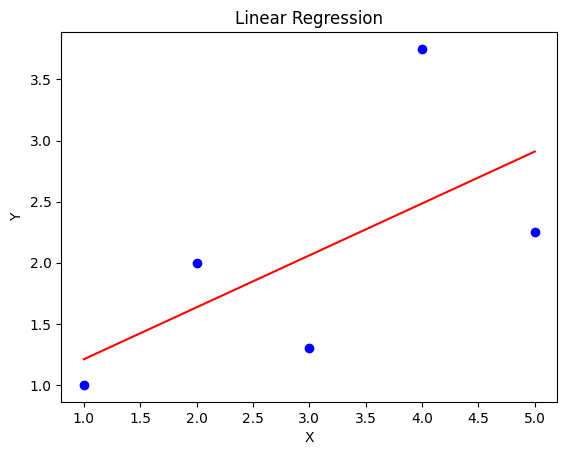

In [1]:
# Exp 1.1 Simple linear regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([[1],[2],[3],[4],[5]])
Y = np.array([1.0, 2.0, 1.3, 3.75, 2.25])

model = LinearRegression().fit(X, Y)
Y_pred = model.predict(X)

print(f"Y' = {model.coef_[0]:.3f}X + {model.intercept_:.3f}")

plt.scatter(X, Y, color='blue')
plt.plot(X, Y_pred, color='red')
plt.title('Linear Regression'); plt.xlabel('X'); plt.ylabel('Y')
plt.show()

Y' = 1.000 + 0.500X1 + 0.500X2


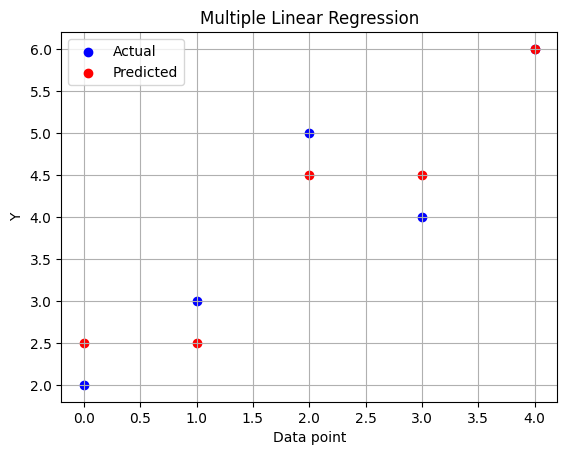

In [2]:
# Exp 1.2 Multiple Linear Regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([[1, 2], [2, 1], [3, 4], [4, 3], [5, 5]])
Y = np.array([2, 3, 5, 4, 6])

model = LinearRegression().fit(X, Y)
Y_pred = model.predict(X)

print(f"Y' = {model.intercept_:.3f} + {model.coef_[0]:.3f}X1 + {model.coef_[1]:.3f}X2")

plt.scatter(range(len(Y)), Y, color='blue', label='Actual')
plt.scatter(range(len(Y)), Y_pred, color='red', label='Predicted')
plt.title('Multiple Linear Regression'); plt.xlabel('Data point'); plt.ylabel('Y')
plt.legend(); plt.grid(True); plt.show()

Accuracy: 95.00%


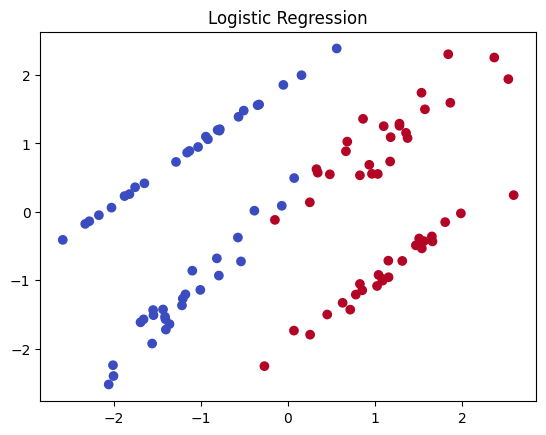

In [3]:
# Exp 2 Logistic Regression
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
m = LogisticRegression().fit(X_train, y_train)
print(f"Accuracy: {accuracy_score(y_test, m.predict(X_test))*100:.2f}%")
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm'); plt.title("Logistic Regression"); plt.show()

In [4]:
# Exp 3.1 Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
iris = load_iris()
X, y = iris.data, iris.target
bagging_model = BaggingClassifier(
 estimator=DecisionTreeClassifier(),
 n_estimators=10,
 random_state=42
)
scores_bag = cross_val_score(bagging_model, X, y, cv=5)
print("Bagging CV Accuracies:", scores_bag)
print("Bagging Mean Accuracy:", scores_bag.mean())

Bagging CV Accuracies: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Bagging Mean Accuracy: 0.9533333333333334


In [5]:
# Exp 3.2 Boosting
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
iris = load_iris()
X, y = iris.data, iris.target
boosting_model = AdaBoostClassifier(
 estimator=DecisionTreeClassifier(max_depth=1),
 n_estimators=50,
 learning_rate=1.0,
 random_state=42
)
scores_boost = cross_val_score(boosting_model, X, y, cv=5)
print("Boosting CV Accuracies:", scores_boost)
print("Boosting Mean Accuracy:", scores_boost.mean())

Boosting CV Accuracies: [0.96666667 0.96666667 0.93333333 0.9        1.        ]
Boosting Mean Accuracy: 0.9533333333333334


In [6]:
# Exp 4 Multivariate Linear Regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.DataFrame({
  'Feature1':[2,3,4,5,6,7,8],
  'Feature2':[1,4,6,3,5,7,9],
  'Feature3':[3,5,7,8,5,6,7],
  'Target':[10,15,20,25,30,35,40]
})
X, y = df[['Feature1','Feature2','Feature3']], df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
print("Coefficients:", model.coef_, "\nIntercept:", model.intercept_)
vals = [[float(input("Feature1: ")), float(input("Feature2: ")), float(input("Feature3: "))]]
print("Predicted Target:", model.predict(vals)[0])


Coefficients: [ 5.00000000e+00 -7.85814516e-16 -5.09361312e-17] 
Intercept: 1.0658141036401503e-14
Feature1: 4
Feature2: 3
Feature3: 5
Predicted Target: 20.000000000000004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
# Exp 5 SVM
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
iris = datasets.load_iris()
X, y = iris.data, iris.target
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
scores = cross_val_score(svm_model, X, y, cv=5)
print("SVM CV Accuracies:", scores)
print("SVM Mean Accuracy:", scores.mean())

SVM CV Accuracies: [0.96666667 1.         0.96666667 0.96666667 1.        ]
SVM Mean Accuracy: 0.9800000000000001


Cluster 1: [1, 2, 3]
Cluster 2: [4, 5, 6, 7, 8]


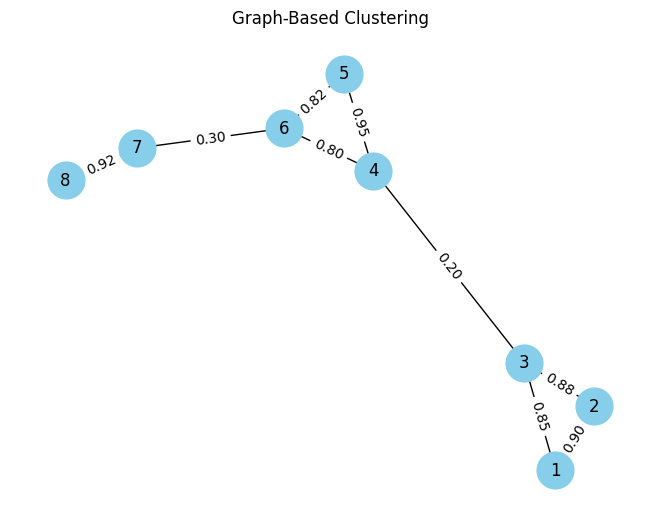

In [8]:
# Exp 6 Graph Based Clustering
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community
G = nx.Graph()
edges = [(1,2,0.9),(1,3,0.85),(2,3,0.88),(4,5,0.95),(4,6,0.8),
         (5,6,0.82),(7,8,0.92),(3,4,0.2),(6,7,0.3)]
G.add_weighted_edges_from(edges)
clusters = tuple(sorted(c) for c in next(community.girvan_newman(G)))
for i,c in enumerate(clusters,1): print(f"Cluster {i}: {list(c)}")
pos = nx.spring_layout(G)
nx.draw(G,pos,with_labels=True,node_color="skyblue",node_size=700)
nx.draw_networkx_edge_labels(G,pos,edge_labels={(u,v):f"{d:.2f}" for u,v,d in edges})
plt.title("Graph-Based Clustering"); plt.show()

Original: (150, 4) Reduced: (150, 2) Explained Var: [0.72962445 0.22850762]


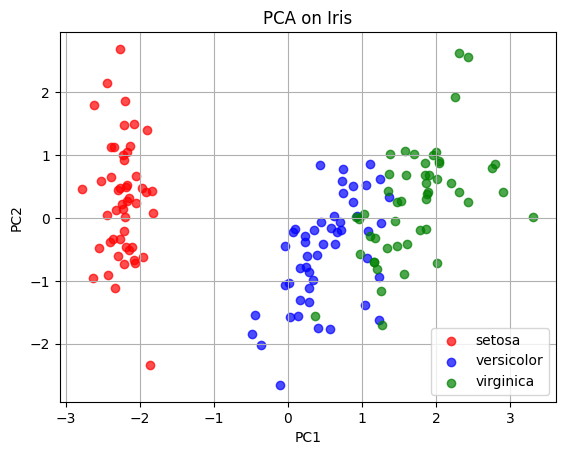

In [9]:
# Exp 7 PCA
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)
print("Original:", X.shape, "Reduced:", X_pca.shape, "Explained Var:", PCA(n_components=2).fit(X_scaled).explained_variance_ratio_)
for t, c, l in zip([0,1,2], ['red','blue','green'], load_iris().target_names):
    plt.scatter(X_pca[y==t,0], X_pca[y==t,1], color=c, label=l, alpha=0.7)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA on Iris"); plt.legend(); plt.grid(True); plt.show()

Estimated number of clusters: 2


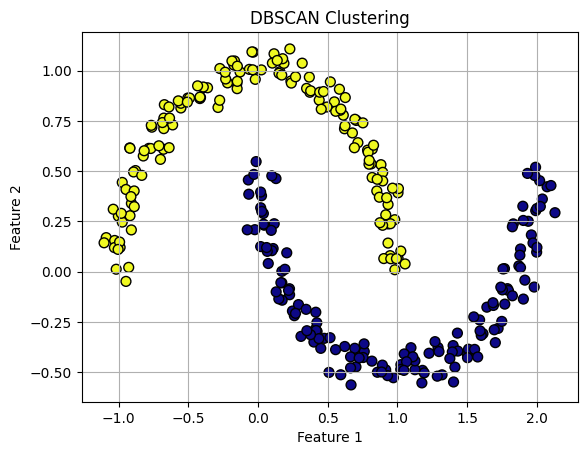

In [10]:
# Exp 8 DBSCAN
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)
print("Estimated number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='plasma', s=50, edgecolor='k')
plt.title("DBSCAN Clustering"); plt.xlabel("Feature 1"); plt.ylabel("Feature 2"); plt.grid(True); plt.show()